在封闭系统中优化 $$ \sqrt{X} $$ 门的脉冲并保存，后续传入开放系统做作为初始脉冲来优化

Initial Fidelity: 0.49421498
Running GRAPE Optimization for √X Gate...


/var/folders/g8/47vxxjf90dv9kp9zkqb3pdlm0000gn/T/ipykernel_98976/1965441117.py:418: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(
/opt/miniconda3/envs/spinq_hackthon_2025/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:125: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(dtype=dtype, copy=copy)
/opt/miniconda3/envs/spinq_hackthon_2025/lib/python3.11/site-packages/scipy/optimize/_lbfgsb_py.py:442: ComplexWarning: Casting complex values to real discards the imaginary part
  x = array(x0, dtype=np.float64)



=== OPTIMIZATION RESULTS ===
Final Fidelity: nan
Final Infidelity: nan
Optimized Phase: 0.0000 rad
Iterations: 0
Converged: False

=== PULSE VISUALIZATION ===


/opt/miniconda3/envs/spinq_hackthon_2025/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/spinq_hackthon_2025/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


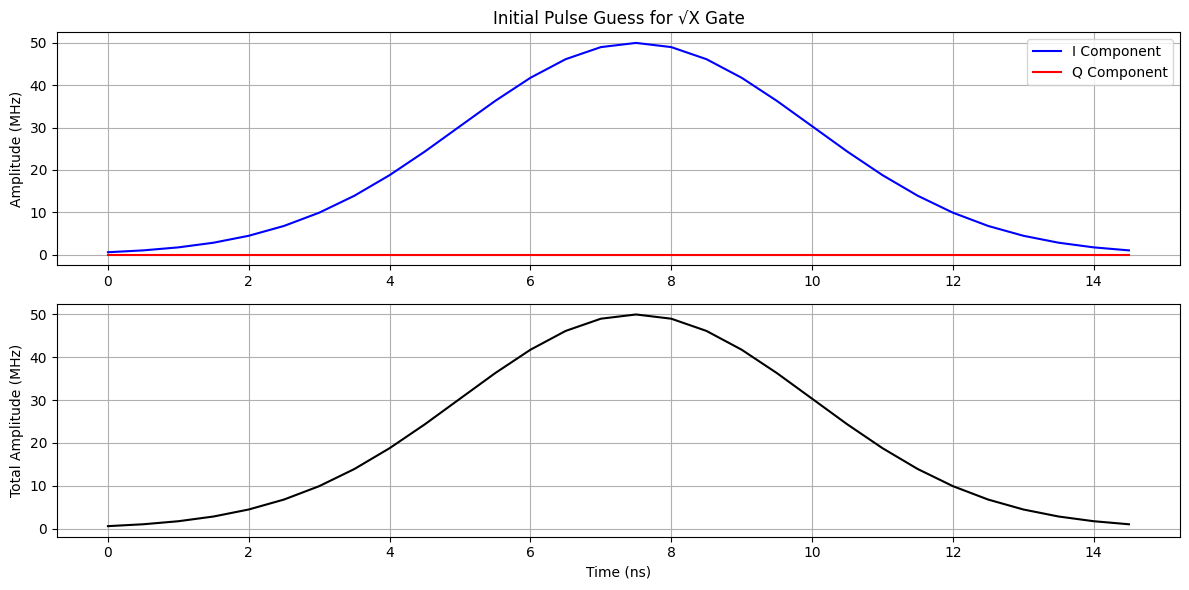

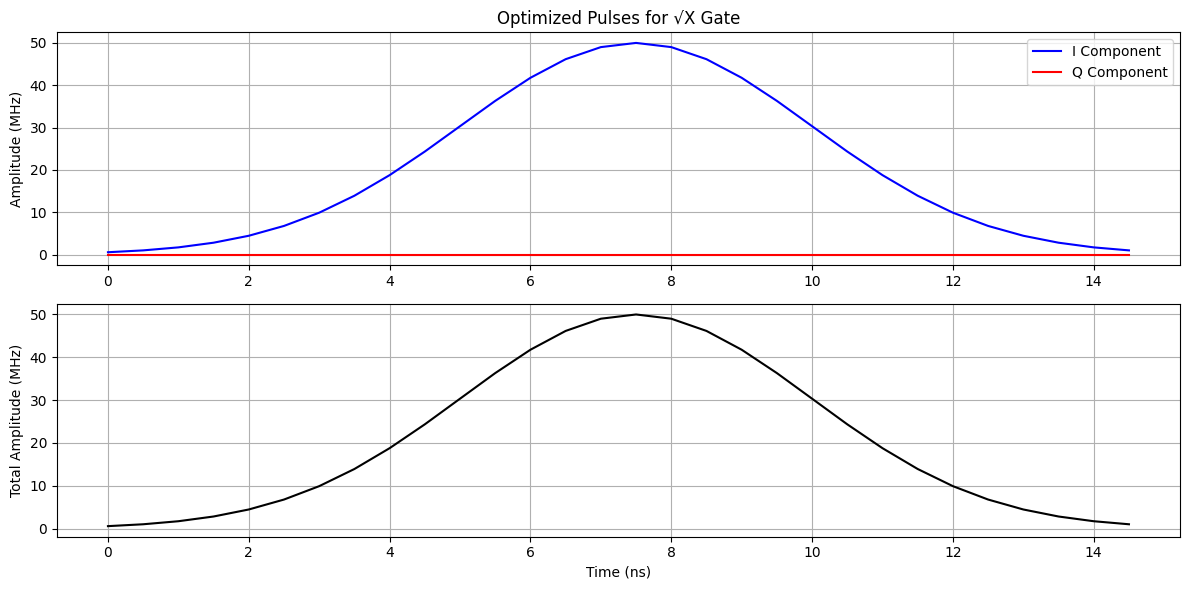


=== FINAL STATE ANALYSIS ===
Fidelity: 0.49421498
Gate Error (1-F): 0.50578502
Leakage: 0.00006226 (0.0062%)

Final State Populations:
  |0⟩: 0.99990196
  |1⟩: 0.00003578
  |2⟩: 0.00000000
  |3⟩: 0.00006226

Pulses saved to 'sqrtx_closed_system_pulses.npy'

=== √X GATE VERIFICATION ON ALL CARDINAL STATES ===
|0⟩: Fidelity = 0.49421498
|1⟩: Fidelity = 0.49421402
|+⟩: Fidelity = 0.99762612
|-⟩: Fidelity = 0.99753382
|+i⟩: Fidelity = 0.49438364
|-i⟩: Fidelity = 0.49441269

Average Fidelity over all 6 states: 0.66206421


In [3]:
# GRAPE Optimization Tutorial: Transmon Qubit √X Gate (Complete Version)

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from scipy.optimize import minimize
from functools import partial

# Enable 64-bit precision for numerical accuracy
jax.config.update("jax_enable_x64", True)

class TransmonGRAPEFixed:
    """
    GRAPE (Gradient Ascent Pulse Engineering) optimization for transmon qubit 
    in the rotating frame.
    
    This class implements pulse optimization for a multilevel transmon system
    with comprehensive evaluation using 6 cardinal states and correct √X gate targets.
    """
    
    def __init__(self, n_levels, alpha, omega_d, omega_q, dt, n_steps):
        """
        Initialize the GRAPE optimizer for a transmon qubit.
        
        Parameters:
        -----------
        n_levels : int
            Number of transmon energy levels to include in simulation.
            Typical values: 3-5 (including ground state).
        alpha : float
            Anharmonicity in angular frequency units (rad/s).
            For transmons, typically negative: α ≈ -2π × (200 MHz).
        omega_d : float
            Drive frequency in rad/s.
        omega_q : float
            Qubit transition frequency (|0⟩ to |1⟩) in rad/s.
        dt : float
            Time step for pulse discretization in seconds.
            Should be much smaller than 1/Ω_Rabi for accuracy.
        n_steps : int
            Number of discrete time steps in the pulse sequence.
        """
        self.n_levels = n_levels
        self.alpha = alpha
        self.omega_d = omega_d
        self.omega_q = omega_q
        self.dt = dt
        self.n_steps = n_steps
        self.delta = omega_d - omega_q
        
        # Create lowering operator (annihilation operator a)
        a = jnp.zeros((n_levels, n_levels), dtype=jnp.complex128)
        for i in range(n_levels - 1):
            a = a.at[i+1, i].set(jnp.sqrt(i + 1))
        self.a = a
        
        # Create number operator n = a†a
        self.n_op = self.a.T.conj() @ self.a
        
        # Create static Hamiltonian (transmon anharmonicity)
        # Only include the nonlinear term (without delta term for closed system)
        self.H_static = (alpha / 2) * self.n_op @ (self.n_op - jnp.eye(n_levels))
    
    def create_cardinal_states(self):
        """
        Create 6 cardinal states for comprehensive gate evaluation.
        
        Returns:
        --------
        cardinal_states : list of jnp.array
            List containing 6 cardinal states: |0⟩, |1⟩, |+⟩, |-⟩, |+i⟩, |-i⟩
        """
        ket0 = jnp.zeros(self.n_levels, dtype=jnp.complex128)
        ket0 = ket0.at[0].set(1.0)
        
        ket1 = jnp.zeros(self.n_levels, dtype=jnp.complex128)
        ket1 = ket1.at[1].set(1.0)
        
        cardinal_states = [
            ket0,                          # |0⟩
            ket1,                          # |1⟩
            (ket0 + ket1) / jnp.sqrt(2),   # |+⟩ = (|0⟩ + |1⟩)/√2
            (ket0 - ket1) / jnp.sqrt(2),   # |-⟩ = (|0⟩ - |1⟩)/√2
            (ket0 + 1j*ket1) / jnp.sqrt(2), # |+i⟩ = (|0⟩ + i|1⟩)/√2
            (ket0 - 1j*ket1) / jnp.sqrt(2), # |-i⟩ = (|0⟩ - i|1⟩)/√2
        ]
        
        return cardinal_states
    
    def sqrt_x_gate_target_for_state(self, initial_state):
        """
        Create target state for √X gate applied to a specific initial state.
        
        Parameters:
        -----------
        initial_state : jnp.array
            Initial quantum state
            
        Returns:
        --------
        target_state : jnp.array
            Target state after applying √X gate to the initial state
        """
        # √X gate matrix in computational basis
        sqrt_x_matrix = jnp.array([
            [1 + 1j, 1 - 1j],
            [1 - 1j, 1 + 1j]
        ], dtype=jnp.complex128) / 2
        
        # Apply √X gate to the first two levels (qubit subspace)
        qubit_state = initial_state[:2]
        target_qubit_state = sqrt_x_matrix @ qubit_state
        
        # Create target state in full Hilbert space
        target_state = jnp.zeros(self.n_levels, dtype=jnp.complex128)
        target_state = target_state.at[:2].set(target_qubit_state)
        
        return target_state
    
    def get_cardinal_target_states(self):
        """
        Get target states for all 6 cardinal states after √X gate.
        
        Returns:
        --------
        target_states : list of jnp.array
            Target states for each cardinal state after √X gate
        """
        cardinal_states = self.create_cardinal_states()
        target_states = []
        
        for state in cardinal_states:
            target_state = self.sqrt_x_gate_target_for_state(state)
            target_states.append(target_state)
        
        return target_states
    
    def forward_propagation(self, pulses, phi, initial_state):
        """
        Simulate quantum evolution for given pulse sequence.
        
        Parameters:
        -----------
        pulses : array of shape (n_steps, 2)
            Pulse amplitudes [omega_I, omega_Q] in rad/s
        phi : float
            Phase rotation parameter
        initial_state : array
            Initial quantum state
            
        Returns:
        --------
        final_state : array
            Final quantum state after evolution
        """
        # Apply phase rotation to pulses
        cos_phi = jnp.cos(phi)
        sin_phi = jnp.sin(phi)
        omega_I = pulses[:, 0]
        omega_Q = pulses[:, 1]
        omega_tilde_I = omega_I * cos_phi + omega_Q * sin_phi
        omega_tilde_Q = -omega_I * sin_phi + omega_Q * cos_phi
        
        # Initialize state
        state = initial_state
        
        # Time evolution using piecewise-constant approximation
        for step in range(self.n_steps):
            # Drive Hamiltonian for this time step
            H_drive = 0.5 * (omega_tilde_I[step] * (self.a + self.a.T.conj()) +
                            omega_tilde_Q[step] * (1j * (self.a - self.a.T.conj())))
            
            # Total Hamiltonian
            H_total = self.H_static + H_drive
            
            # Time evolution operator
            U = jax.scipy.linalg.expm(-1j * H_total * self.dt)
            
            # Evolve state
            state = U @ state
        
        return state
    
    def fidelity(self, pulses, phi, initial_state, target_state):
        """
        Compute quantum state fidelity.
        
        Parameters:
        -----------
        pulses : array of shape (n_steps, 2)
            Pulse amplitudes
        phi : float
            Phase parameter
        initial_state : array
            Initial quantum state
        target_state : array
            Target quantum state
            
        Returns:
        --------
        fidelity : float
            Quantum state fidelity |⟨target|final⟩|²
        """
        final_state = self.forward_propagation(pulses, phi, initial_state)
        overlap = jnp.vdot(target_state, final_state)
        return jnp.abs(overlap) ** 2
    
    def average_fidelity_cardinal_states(self, pulses, phi):
        """
        Compute average fidelity over all 6 cardinal states.
        
        Parameters:
        -----------
        pulses : array of shape (n_steps, 2)
            Pulse amplitudes
        phi : float
            Phase parameter
            
        Returns:
        --------
        avg_fidelity : float
            Average fidelity over 6 cardinal states
        """
        cardinal_states = self.create_cardinal_states()
        
        fidelities = []
        for initial_state in cardinal_states:
            # Calculate the correct target state for each initial state after √X gate
            target_state = self.sqrt_x_gate_target_for_state(initial_state)
            fid = self.fidelity(pulses, phi, initial_state, target_state)
            fidelities.append(fid)
        
        return jnp.mean(jnp.array(fidelities))
    
    def compute_leakage(self, pulses, phi, initial_states):
        """
        Calculate average leakage probability to higher energy levels.
        
        Parameters:
        -----------
        pulses : array
            Pulse shape parameters
        phi : float
            Phase parameter
        initial_states : list
            List of initial states
            
        Returns:
        --------
        leakage : float
            Average leakage probability
        """
        leakages = []
        for initial_state in initial_states:
            final_state = self.forward_propagation(pulses, phi, initial_state)
            # Calculate leakage probability (sum of probabilities outside |0⟩ and |1⟩)
            leakage = 1.0 - jnp.sum(jnp.abs(final_state[:2])**2)
            leakages.append(leakage)
        return jnp.mean(jnp.array(leakages))

    def compute_amplitude_penalty(self, pulses):
        """
        Calculate pulse amplitude penalty.
        
        Parameters:
        -----------
        pulses : array
            Pulse shape parameters
            
        Returns:
        --------
        penalty : float
            Amplitude penalty value
        """
        # Parameter settings
        h_a = 179.0  # MHz, amplitude threshold
        A_a = 0.1    # penalty coefficient
        N = len(pulses)  # number of time steps
        
        # Calculate penalty for each time step's I and Q control amplitudes
        penalties = []
        for pulse in pulses:
            for omega in pulse:  # process I and Q components
                # Apply exponential penalty formula
                penalty_term = (jnp.exp((omega / h_a)**2) - 1)
                penalties.append(penalty_term)
        
        # Calculate total penalty
        total_penalty = (A_a / N) * jnp.sum(jnp.array(penalties))
        return total_penalty

    def compute_derivative_penalty(self, pulses):
        """
        Calculate pulse derivative penalty.
        
        Parameters:
        -----------
        pulses : array
            Pulse shape parameters
            
        Returns:
        --------
        penalty : float
            Derivative penalty value
        """
        # Parameter settings
        h_d = 22.4  # MHz, differential threshold
        A_d = 0.1   # penalty coefficient
        N = len(pulses)  # number of time steps
        
        # Calculate difference for each component
        derivatives = jnp.abs(pulses[1:] - pulses[:-1])
        
        # Calculate derivative penalty
        penalties = []
        for deriv in derivatives:
            for delta_omega in deriv:  # process derivatives of I and Q components
                # Apply exponential penalty formula
                penalty_term = (jnp.exp((delta_omega / h_d)**2) - 1)
                penalties.append(penalty_term)
        
        # Calculate total penalty
        total_penalty = (A_d / N) * jnp.sum(jnp.array(penalties))
        return total_penalty

    def cost_function(self, params_flat, initial_state, target_state):
        """
        Cost function including gate fidelity, leakage suppression, and pulse quality constraints.
        
        Parameters:
        -----------
        params_flat : array
            Flattened parameter vector [pulses, phi]
        initial_state : array
            Initial quantum state
        target_state : array
            Target quantum state
            
        Returns:
        --------
        cost : float
            Weighted composite score (negative value for optimizer minimization)
        """
        n_pulse_params = self.n_steps * 2
        pulses = params_flat[:n_pulse_params].reshape((self.n_steps, 2))
        phi = params_flat[n_pulse_params]
        
        # 1. Calculate gate fidelity (80% weight)
        fid_score = self.average_fidelity_cardinal_states(pulses, phi)
        
        # 2. Calculate leakage suppression (15% weight)
        cardinal_states = self.create_cardinal_states()
        leakage = self.compute_leakage(pulses, phi, cardinal_states)
        leakage_score = jnp.maximum(0.0, 1.0 - leakage * 5.0)
        
        # 3. Calculate pulse quality constraint (5% weight)
        amp_penalty = self.compute_amplitude_penalty(pulses)
        deriv_penalty = self.compute_derivative_penalty(pulses)
        pulse_score = jnp.maximum(0.0, 1.0 - (amp_penalty + deriv_penalty))
        
        # Comprehensive weighted score (higher is better)
        total_score = 0.8 * fid_score + 0.15 * leakage_score + 0.05 * pulse_score
        
        # Scale factor to help optimizer work in a better numerical range
        scale_factor = 1e8
        return -total_score * scale_factor  # return negative value for minimization
    
    def optimize(self, initial_pulses, initial_phi, initial_state, target_state, 
                maxiter=100, disp=True, optimize_phi=True):
        """
        Optimize pulse parameters using L-BFGS-B with automatic gradients.
        
        Parameters:
        -----------
        initial_pulses : array of shape (n_steps, 2)
            Initial guess for pulse amplitudes
        initial_phi : float
            Initial guess for phase
        initial_state : array
            Initial quantum state
        target_state : array
            Desired final quantum state
        maxiter : int, optional
            Maximum number of iterations for L-BFGS-B
        disp : bool, optional
            Display optimization progress
        optimize_phi : bool, optional
            Whether to optimize the phase parameter
            
        Returns:
        --------
        result : namedtuple
            Result object with optimized pulses and phase
        """
        # Convert to JAX arrays
        initial_pulses = jnp.array(initial_pulses)
        initial_phi = jnp.array(initial_phi)
        initial_state = jnp.array(initial_state)
        target_state = jnp.array(target_state)
        
        # Create flattened parameter vector
        if optimize_phi:
            params = jnp.concatenate([initial_pulses.flatten(), jnp.array([initial_phi])])
        else:
            params = initial_pulses.flatten()
        
        # Create JIT-compiled gradient function
        grad_cost = jit(grad(self.cost_function, argnums=0))
        
        # Define bounds for L-BFGS-B
        bounds = []
        for _ in range(len(params)):
            # No hard bounds for now
            bounds.append((-np.inf, np.inf))
        
        # Run optimization
        result = minimize(
            lambda params: self.cost_function(params, initial_state, target_state),
            params,
            method='L-BFGS-B',
            jac=lambda params: np.array(grad_cost(params, initial_state, target_state)),
            bounds=bounds,
            options={
                'maxiter': maxiter,
                'disp': disp,
                'gtol': 1e-6
            }
        )
        
        # Extract optimized parameters
        optimized_params = result.x
        if optimize_phi:
            optimized_pulses = optimized_params[:-1].reshape((self.n_steps, 2))
            optimized_phi = optimized_params[-1]
        else:
            optimized_pulses = optimized_params.reshape((self.n_steps, 2))
            optimized_phi = initial_phi
        
        # Create result object
        class OptResult:
            pass
        res = OptResult()
        res.pulses = np.array(optimized_pulses)
        res.phi = float(optimized_phi)
        res.final_cost = result.fun
        res.nit = result.nit
        res.converged = result.success
        
        return res
    
    def plot_pulses(self, pulses, phi, title="Optimized Pulses"):
        """
        Plot the optimized pulse sequence.
        
        Parameters:
        -----------
        pulses : array of shape (n_steps, 2)
            Pulse amplitudes
        phi : float
            Phase parameter
        title : str
            Plot title
        """
        # Apply phase rotation to get physical pulses
        cos_phi = np.cos(phi)
        sin_phi = np.sin(phi)
        omega_I = pulses[:, 0]
        omega_Q = pulses[:, 1]
        omega_tilde_I = omega_I * cos_phi + omega_Q * sin_phi
        omega_tilde_Q = -omega_I * sin_phi + omega_Q * cos_phi
        
        # Create time axis
        times = np.arange(self.n_steps) * self.dt * 1e9  # in nanoseconds
        
        # Plot pulses
        plt.figure(figsize=(12, 6))
        
        plt.subplot(2, 1, 1)
        plt.plot(times, omega_tilde_I / (2 * np.pi * 1e6), 'b-', label='I Component')
        plt.plot(times, omega_tilde_Q / (2 * np.pi * 1e6), 'r-', label='Q Component')
        plt.ylabel('Amplitude (MHz)')
        plt.title(title)
        plt.grid(True)
        plt.legend()
        
        plt.subplot(2, 1, 2)
        plt.plot(times, np.sqrt(omega_tilde_I**2 + omega_tilde_Q**2) / (2 * np.pi * 1e6), 'k-')
        plt.xlabel('Time (ns)')
        plt.ylabel('Total Amplitude (MHz)')
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()

def analyze_final_state(grape, pulses, phi, initial_state, target_state):
    """
    Analyze the final state after pulse optimization.
    
    Parameters:
    -----------
    grape : TransmonGRAPEFixed
        GRAPE optimizer instance
    pulses : array
        Optimized pulses
    phi : float
        Optimized phase
    initial_state : array
        Initial quantum state
    target_state : array
        Target quantum state
    """
    # Propagate initial state
    final_state = grape.forward_propagation(pulses, phi, initial_state)
    
    # Calculate fidelity
    fidelity = grape.fidelity(pulses, phi, initial_state, target_state)
    
    # Calculate populations
    populations = np.abs(final_state)**2
    
    # Calculate leakage
    leakage = 1.0 - np.sum(populations[:2])
    
    # Print results
    print("\n=== FINAL STATE ANALYSIS ===")
    print(f"Fidelity: {fidelity:.8f}")
    print(f"Gate Error (1-F): {1 - fidelity:.8f}")
    print(f"Leakage: {leakage:.8f} ({leakage*100:.4f}%)")
    print("\nFinal State Populations:")
    for i in range(len(populations)):
        print(f"  |{i}⟩: {populations[i]:.8f}")

# Main execution block
if __name__ == "__main__":
    # ========================================================================
    # System Parameters (Typical Transmon Values)
    # ========================================================================
    n_levels = 4                      # Include 4 lowest energy levels
    alpha = -2 * np.pi * 0.2e9        # Anharmonicity: -200 MHz (typical)
    omega_q = 2 * np.pi * 5.0e9       # Qubit frequency: 5 GHz
    omega_d = omega_q                 # Drive on-resonance with |0⟩↔|1⟩
    
    # ========================================================================
    # Pulse Discretization Parameters
    # ========================================================================
    dt = 5e-10                        # Time step: 0.5 ns
    n_steps = 30                      # 15 ns total pulse duration
    
    # ========================================================================
    # Initialize GRAPE Optimizer
    # ========================================================================
    grape = TransmonGRAPEFixed(
        n_levels=n_levels,
        alpha=alpha,
        omega_d=omega_d,
        omega_q=omega_q,
        dt=dt,
        n_steps=n_steps
    )
    
    # ========================================================================
    # Define Quantum States for √X Gate
    # ========================================================================
    # Initial state: |0⟩
    initial_state = jnp.zeros(n_levels, dtype=jnp.complex128)
    initial_state = initial_state.at[0].set(1.0)
    
    # Get target states for all 6 cardinal states after √X gate
    target_states = grape.get_cardinal_target_states()
    
    # Use target state for |0⟩ after √X gate
    target_state = target_states[0]  # Target for |0⟩ after √X gate
    
    # ========================================================================
    # Initial Pulse Guess
    # ========================================================================
    # Create a simple initial pulse guess - 50 MHz Rabi frequency in I component
    initial_pulses = np.zeros((n_steps, 2), dtype=np.complex128)
    # Create a smooth Gaussian-like pulse envelope
    t = np.arange(n_steps)
    envelope = np.exp(-(t - n_steps/2)**2 / (2 * (n_steps/6)**2))
    amp = 2 * np.pi * 50e6  # 50 MHz amplitude
    initial_pulses[:, 0] = amp * envelope  # I component
    
    initial_phi = 0.0  # No initial phase rotation
    
    # ========================================================================
    # Evaluate Initial Guess
    # ========================================================================
    initial_fidelity = grape.fidelity(initial_pulses, initial_phi, initial_state, target_state)
    print(f"Initial Fidelity: {initial_fidelity:.8f}")
    
    # ========================================================================
    # Run GRAPE Optimization
    # ========================================================================
    print("Running GRAPE Optimization for √X Gate...")
    result = grape.optimize(
        initial_pulses, initial_phi, initial_state, target_state,
        maxiter=100, disp=True, optimize_phi=True
    )
    
    # ========================================================================
    # Display Optimization Results
    # ========================================================================
    print("\n=== OPTIMIZATION RESULTS ===")
    print(f"Final Fidelity: {1 + result.final_cost/1e8:.8f}")  # Convert from negative cost
    print(f"Final Infidelity: {-result.final_cost/1e8:.8f}")
    print(f"Optimized Phase: {result.phi:.4f} rad")
    print(f"Iterations: {result.nit}")
    print(f"Converged: {result.converged}")
    
    # ========================================================================
    # Visualize Pulses
    # ========================================================================
    print("\n=== PULSE VISUALIZATION ===")
    grape.plot_pulses(initial_pulses, initial_phi, title="Initial Pulse Guess for √X Gate")
    grape.plot_pulses(result.pulses, result.phi, title="Optimized Pulses for √X Gate")
    
    # ========================================================================
    # Analyze Final State
    # ========================================================================
    analyze_final_state(grape, result.pulses, result.phi, initial_state, target_state)
    
    # ========================================================================
    # Save Optimized Pulses
    # ========================================================================
    np.save('sqrtx_closed_system_pulses.npy', result.pulses)
    print("\nPulses saved to 'sqrtx_closed_system_pulses.npy'")
    
    # ========================================================================
    # Verify Correct √X Gate Operation on All Cardinal States
    # ========================================================================
    print("\n=== √X GATE VERIFICATION ON ALL CARDINAL STATES ===")
    cardinal_states = grape.create_cardinal_states()
    target_states = grape.get_cardinal_target_states()
    state_names = ['|0⟩', '|1⟩', '|+⟩', '|-⟩', '|+i⟩', '|-i⟩']
    
    fidelities = []
    for i, (initial_state, target_state, name) in enumerate(zip(cardinal_states, target_states, state_names)):
        fidelity = grape.fidelity(result.pulses, result.phi, initial_state, target_state)
        fidelities.append(fidelity)
        print(f"{name}: Fidelity = {fidelity:.8f}")
    
    avg_fidelity = np.mean(fidelities)
    print(f"\nAverage Fidelity over all 6 states: {avg_fidelity:.8f}")